### Astrostatistics lesson 1

original array: [0, 0, 1] 

[1, 0, 0]
winning index: 0
picked: 1
exluded: [2]
switcher pick: 0
newcomer pick: 1
conservative pick: 1 

[0, 1, 0]
winning index: 1
picked: 1
exluded: [0, 2]
eliminated index: 0
switcher pick: 2
newcomer pick: 2
conservative pick: 1 

[0, 0, 1]
winning index: 2
picked: 1
exluded: [0]
switcher pick: 2
newcomer pick: 2
conservative pick: 1 

[0, 0, 1]
winning index: 2
picked: 1
exluded: [0]
switcher pick: 2
newcomer pick: 1
conservative pick: 1 

[1, 0, 0]
winning index: 0
picked: 0
exluded: [1, 2]
eliminated index: 1
switcher pick: 2
newcomer pick: 2
conservative pick: 0 

[0, 1, 0]
winning index: 1
picked: 2
exluded: [0]
switcher pick: 1
newcomer pick: 1
conservative pick: 2 

[1, 0, 0]
winning index: 0
picked: 1
exluded: [2]
switcher pick: 0
newcomer pick: 0
conservative pick: 1 

[1, 0, 0]
winning index: 0
picked: 1
exluded: [2]
switcher pick: 0
newcomer pick: 1
conservative pick: 1 

[0, 0, 1]
winning index: 2
picked: 2
exluded: [0, 1]
eliminated index:

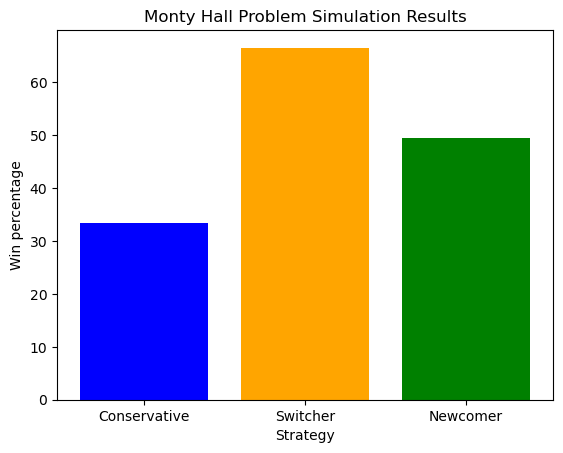

In [94]:
#first we create an array with 3 entry 
import random
import numpy as np 
import matplotlib.pyplot as plt

N=10000
i = 0
c_win = 0
s_win = 0
n_win = 0

#we shuffle the array to randomize the order of the entries
my_array = [0, 0, 1]
print("original array:", my_array, "\n")

while i < N:
    random.shuffle(my_array)
    print(my_array)
    #record the index of the 1 in the array
    winning_index = np.where(np.array(my_array) == 1)[0][0]
    print("winning index:", winning_index)

    #then we make the first two pick an index in the array 
    first_pick = random.randint(0, 2)
    print("picked:", first_pick)

    #eliminate the other index that is not the 1 and not the first pick
    excluded_index  = [i for i in range(3) if i != first_pick and i != winning_index]
    print("exluded:", excluded_index)
    #In case we have 2 ramaining indices, we randomly eliminate one of them
    if len(excluded_index) > 1:
        eliminated_index = random.choice(excluded_index)
        print("eliminated index:", eliminated_index)
        #the switcher changes to the other index
        switcher_pick = [i for i in range(3) if i != first_pick and i != eliminated_index][0]
        print("switcher pick:", switcher_pick)
        #the third option, the newcomer, randomly picks one of the remaining indices
        newcomer_pick = random.choice([i for i in range(3) if i != eliminated_index])
        print("newcomer pick:", newcomer_pick)
    else :
        switcher_pick = [i for i in range(3) if i != first_pick and i != excluded_index[0]][0]
        print("switcher pick:", switcher_pick)
        newcomer_pick = random.choice([i for i in range(3) if i != excluded_index[0]])
        print("newcomer pick:", newcomer_pick)

    #the conservative doesn't change the first pick
    conservative_pick = first_pick
    print("conservative pick:", conservative_pick , "\n")

    #finally we check if the picks are correct
    if conservative_pick == winning_index:
        c_win += 1
    if switcher_pick == winning_index:
        s_win += 1
    if newcomer_pick == winning_index:
        n_win += 1
    i += 1
print("Conservative wins:", c_win)
print("Switcher wins:", s_win)
print("Newcomer wins:", n_win)

plt.bar(['Conservative', 'Switcher', 'Newcomer'], [100*c_win/N, 100*s_win/N, 100*n_win/N], color=['blue', 'orange', 'green'])
plt.xlabel('Strategy')
plt.ylabel('Win percentage')
plt.title('Monty Hall Problem Simulation Results')
plt.show()


### N doors case 

In [ ]:
#Now we can try it for a N numer of doors 